In [3]:
!pip install "gymnasium[mujoco]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 12.8 MB/s eta 0:00:00


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

import multiprocessing
from multiprocessing import Pool

import gymnasium as gym
import sys

# environment
ENV_NAME = 'HalfCheetah-v5'


In [4]:
### neural network

# hyperparameters
env = gym.make(ENV_NAME)
D = np.prod(env.observation_space.shape)
M = 128
K = env.action_space.shape[0]
action_max = env.action_space.high[0]

def relu(x):
  return x * (x > 0)

class ANN:
  def __init__(self, D, M, K, f=relu):
    self.D = D
    self.M = M
    self.K = K
    self.f = f

  def init(self):
    D, M, K = self.D, self.M, self.K
    self.W1 = np.random.randn(D, M) / np.sqrt(D)
    self.b1 = np.zeros(M)
    self.W2 = np.random.randn(M, K) / np.sqrt(M)
    self.b2 = np.zeros(K)

  def forward(self, X):
    Z = self.f(X @ self.W1 + self.b1)
    return np.tanh(Z @ self.W2 + self.b2) * action_max

  def sample_action(self, x):
    # assume input is a single state of size (D,)
    # first make it (N, D) to fit ML conventions
    X = np.atleast_2d(x)
    Y = self.forward(X)
    return Y[0] # first row

  def get_params(self):
    # return a flat array of parameters
    return np.concatenate([self.W1.flatten(), self.b1, self.W2.flatten(), self.b2])

  def get_params_dict(self):
    return {
      'W1': self.W1,
      'b1': self.b1,
      'W2': self.W2,
      'b2': self.b2,
    }

  def set_params(self, params):
    # params is a flat list
    # unflatten into individual weights
    D, M, K = self.D, self.M, self.K
    self.W1 = params[:D * M].reshape(D, M)
    self.b1 = params[D * M: D * M + M]
    self.W2 = params[D * M + M: D * M + M + M * K].reshape(M, K)
    self.b2 = params[-K:]

In [5]:
class OnlineStandardScaler:
  def __init__(self, num_inputs):
    self.n = 0
    self.mean = np.zeros(num_inputs)
    self.ssd = np.zeros(num_inputs)

  def partial_fit(self, X):
    self.n += 1
    delta = X - self.mean
    self.mean += delta / self.n
    delta2 = X - self.mean
    self.ssd += delta * delta2

  def transform(self, X):
    m = self.mean
    v = (self.ssd / self.n).clip(min=1e-2)
    s = np.sqrt(v)
    return (X - m) / s


scaler = OnlineStandardScaler(D)

In [6]:
class Optimizer:
  def __init__(self, params, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    self.lr = lr
    self.m = 0 # first moment
    self.v = 0 # second moment
    self.b1 = beta1
    self.b2 = beta2
    self.eps = eps
    self.t = 1 # time step
    self.params = params

#   def update(self, g):
#     # new m
#     self.m = self.b1 * self.m + (1 - self.b1) * g
#     # new v
#     self.v = self.b2 * self.v + (1 - self.b2) * g**2
#     # bias correction
#     m_hat = self.m / (1 - self.b1**self.t)
#     v_hat = self.v / (1 - self.b2**self.t)
#     # update time step
#     self.t += 1
#     # update params
#     self.params += self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
#     return self.params

  def update(self, g):
    # update params
    self.params += self.lr * g
    return self.params

In [7]:
def evolution_strategy(
  f,
  population_size,
  sigma,
  lr,
  initial_params,
  num_iters,
  pool,
  ):

  # assume initial params is a 1-D array
  num_params = len(initial_params)
  reward_per_iteration = np.zeros(num_iters)

  # create optimizer
  params = initial_params
  adam = Optimizer(params, lr)

  for t in range(num_iters):
    t0 = datetime.now()
    eps = np.random.randn(population_size, num_params)

    ### slow way
    # R = np.zeros(population_size)
    # for i in range(population_size):
    #   R[i] = f(params + sigma * eps[i])

    ### fast way
    params_try = [params + sigma * eps[i] for i in range(population_size)] + \
      [params - sigma * eps[i] for i in range(population_size)]
    R = pool.map(f, params_try)
    R = np.array(R)

    # split into positive and negative rewards
    R_pos = R[:population_size]
    R_neg = R[population_size:]

    m = R.mean()
    s = R.std()
    if s == 0:
      # we can't apply the following equation
      print("Skipping")
      continue

    reward_per_iteration[t] = m
    g = eps.T @ (R_pos - R_neg) / (population_size * s)
    params = adam.update(g)

    print("Iter:", t, "Avg Reward:", m, "Max Reward:", R.max(), "Duration:", datetime.now() - t0)

  return params, reward_per_iteration

In [8]:
def reward_function(params, record=False, env_name=ENV_NAME):
  # run one episode of env w/ params
  model = ANN(D, M, K)
  model.set_params(params)

  if record:
    env = gym.make(env_name, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(env, video_folder="videos", episode_trigger=lambda eps: True)
  else:
    env = gym.make(env_name)
  env = gym.wrappers.RecordEpisodeStatistics(env)

  # play one episode and return total reward
  episode_reward = 0
  episode_length = 0
  done = False
  state, _ = env.reset()
  while not done:
    scaler.partial_fit(state)
    state = scaler.transform(state)

    # get action
    action = model.sample_action(state)

    # perform action
    state, reward, done, truncated, info = env.step(action)
    done = done or truncated

    # update total reward and length
    episode_reward += reward
    episode_length += 1

  # close env
  env.close()

  assert(info['episode']['r'] == episode_reward)

  return episode_reward

Iter: 0 Avg Reward: -268.7727476829775 Max Reward: 374.8266413672586 Duration: 0:00:11.837832
Iter: 1 Avg Reward: -138.45185011701813 Max Reward: 673.1596264555521 Duration: 0:00:08.059843
Iter: 2 Avg Reward: -202.16596707736574 Max Reward: 529.5918219610518 Duration: 0:00:09.849241
Iter: 3 Avg Reward: -152.417355538571 Max Reward: 285.33318954419957 Duration: 0:00:09.305360
Iter: 4 Avg Reward: -105.22574968054923 Max Reward: 628.2724511256229 Duration: 0:00:07.946027
Iter: 5 Avg Reward: -77.25403248571962 Max Reward: 790.8681504521071 Duration: 0:00:09.657614
Iter: 6 Avg Reward: -77.27827142522386 Max Reward: 674.6172914206713 Duration: 0:00:09.689152
Iter: 7 Avg Reward: -54.654420669490825 Max Reward: 745.4211427437945 Duration: 0:00:07.807611
Iter: 8 Avg Reward: -3.4043536009118176 Max Reward: 755.5796958084437 Duration: 0:00:09.462929
Iter: 9 Avg Reward: -10.489754683063337 Max Reward: 651.0367042303069 Duration: 0:00:09.307469
Iter: 10 Avg Reward: 65.73244476274613 Max Reward: 928

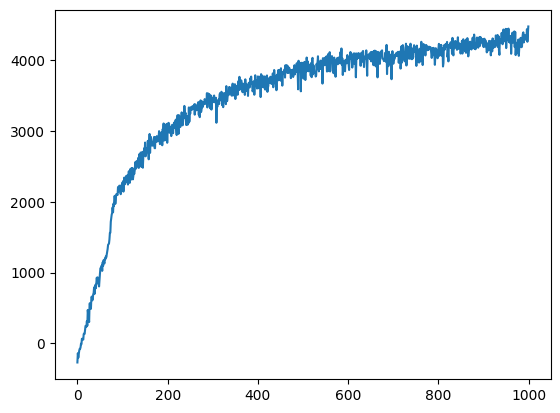

/usr/local/lib/python3.12/dist-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
/usr/local/lib/python3.12/dist-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


FatalError: an OpenGL platform library has not been loaded into this process, this most likely means that a valid OpenGL context has not been created before mjr_makeContext was called

In [9]:
if __name__ == '__main__':

  # create model
  model = ANN(D, M, K)

  if len(sys.argv) > 1 and sys.argv[1] == 'play':
    # play with a saved model
    j = np.load('ars_mujoco_results.npz')
    best_params = np.concatenate([j['W1'].flatten(), j['b1'], j['W2'].flatten(), j['b2']])

    # in case initial shapes are not correct
    # D, M = j['W1'].shape
    # K = len(j['b2'])
    # model.D, model.M, model.K = D, M, K
  else:
    # pool for parallel evaluation
    pool = Pool(4)

    # train and save model
    model.init()
    params = model.get_params()
    best_params, rewards = evolution_strategy(
      f=reward_function,
      population_size=30,
      sigma=0.05,
      lr=0.02,
      initial_params=params,
      num_iters=1000,
      pool=pool,
    )

    # plot the rewards per iteration
    plt.plot(rewards)
    plt.show()

    # save params
    model.set_params(best_params)
    np.savez(
      'ars_mujoco_results.npz',
      train=rewards,
      **model.get_params_dict(),
    )

  # play with saved model / test episode
  print("Test:", reward_function(best_params, record=True))

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=8fP_8gnYambvgyDFSyTaIA&n=ARS+MuJoCo)